# VAT grid — field-aligned instrument ladders + missing mass → missing value
**2026-08-11 (v2).** Uniform field columns on every plot: Math · Coding · Notice & Comment ·
Patents · Peer Review · Journalism · Creative Writing · Humor (the full charter — law is
excluded by design; no field is missing). One canonical cell per field × y-type
(canonical assignments per the strict list). Ladder: `V` → `V_new` → `V+A` → `V+A_new` →
`V+A+T` (best fused arm of any method, incl. the F2 deconfounded stack); dense `T` as
reference diamond. `V_new = V` except code-competitions (discovered ordinals are
covariates by design). Frame flags: `†c` campaign frame, `†f` full-strength bank,
`†wr` within-repo. Missing bars = stage not run or instrument not certified (annotated).

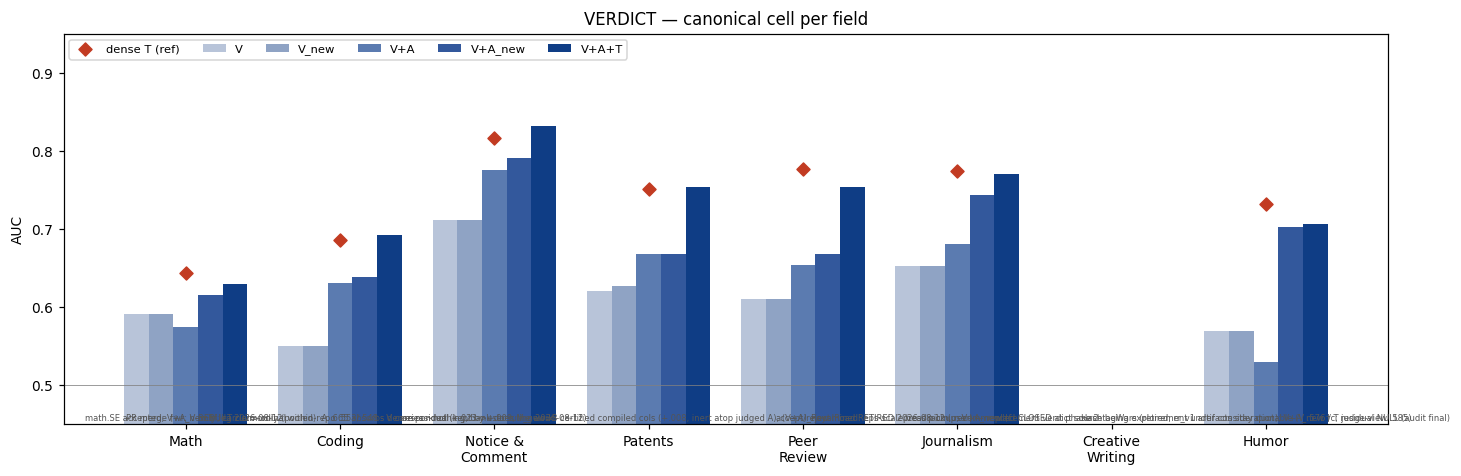

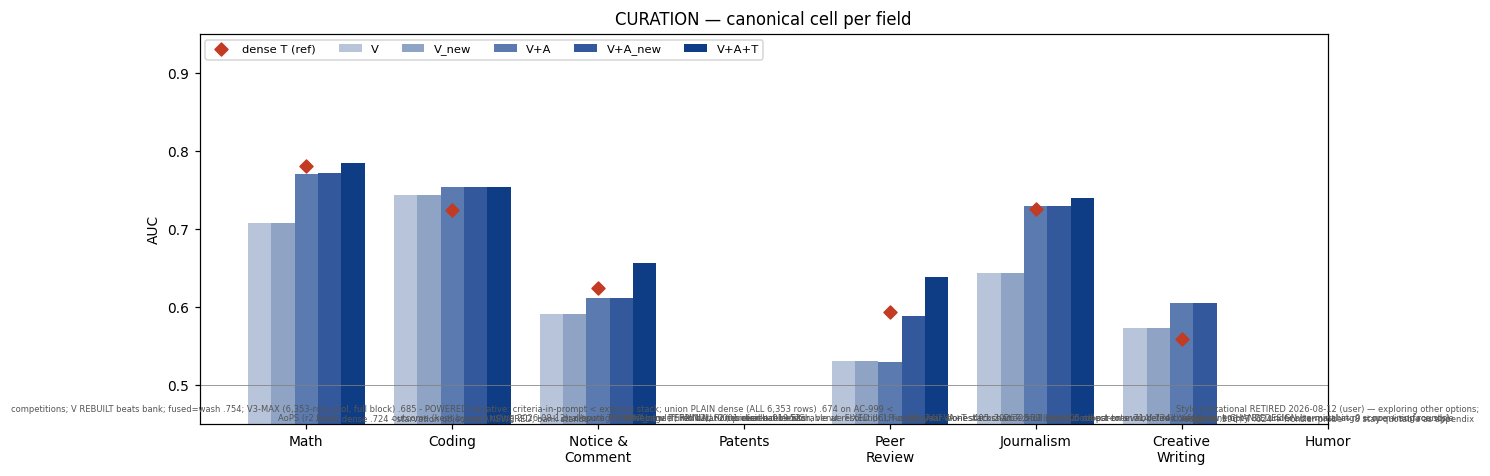

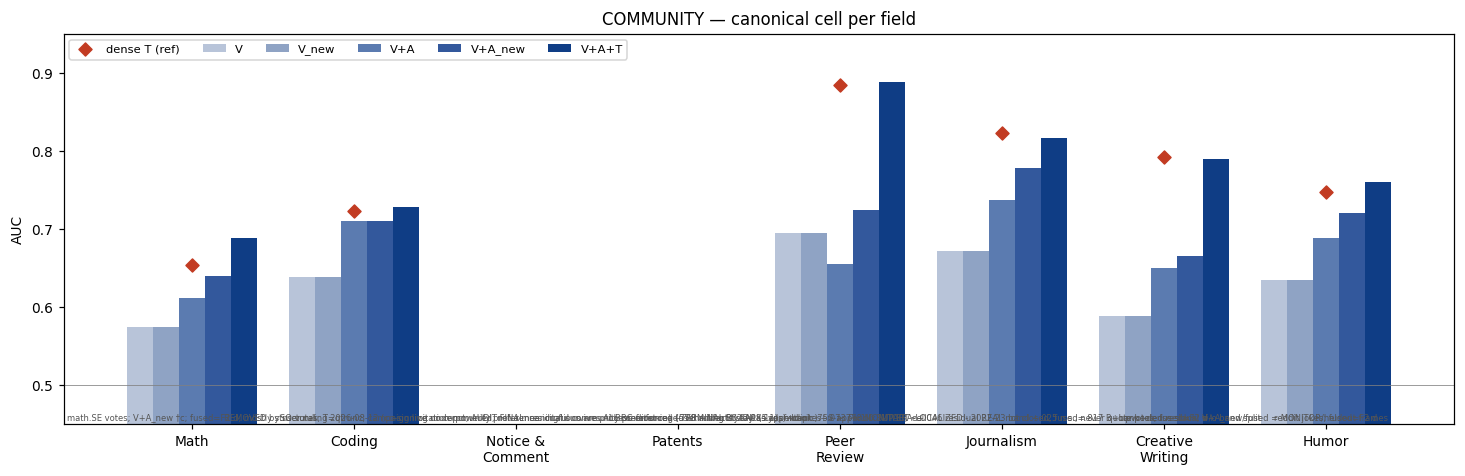

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9})

FIELDS = ["Math", "Coding", "Notice &\nComment", "Patents", "Peer\nReview", "Journalism", "Creative\nWriting", "Humor"]

# (V, V_new, V+A, V+A_new, fused, T, note)   None = unavailable
NA = (None,)*6 + ("",)
VERDICT = {
 "Math":       (.591, None, .632, .616, .630, .644, "math.SE accepted; V+A_new †f; carrier=ordinal; VA CORRECTED 2026-08-18 (.574 was E-refit frame; ledger full-pop VA_nl .632)"),
 "Coding":     (.550, None, .631, .638, .692, .686, "PR merge †wr; V-only leg 2026-08-12: within-repo .553/.548 - V carries ~nothing, bank does the work"),
 "Notice &\nComment": (.711, None, .775, .791, .832, .817, "responded (kept by user ruling 2026-08-12)"),
 "Patents":    (.620, .627, .668, .668, .754, .751, "REBUILT claim-only (pooled): A .665 absorbs dense residual +.023->+.009; V_new=8 certified compiled cols (+.008, inert atop judged A); (V+A)_new-mined: eps-scale headroom, recommended CLOSED at phase 2"),
 "Peer\nReview": (.610, None, .654, .668, .754, .777, "accept/reject"),
 "Journalism": (.653, None, .681, .744, .771, .774, "press pickup; V+A_new †f"),
 "Creative\nWriting": NA[:6] + ("RoyalRoad RETIRED 2026-08-12 (user) — replacement verdict source being explored; rr_v1 artifacts stay quotable (V .576 / T judge-view .585)",),
 "Humor":      (.569, None, .529, .703, .706, .732, "HashtagWars (retirement under consideration); V+A_new †c; residual NULL (audit final)"),
}
CURATION = {
 "Math":       (.708, None, .771, .772, .785, .781, "AoPS (r2 live)"),
 "Coding":     (.743, .743, .754, None, .754, .724, "competitions; V REBUILT beats bank; fused=wash .754; V3-MAX (6,353-row pool, full block) .685 - POWERED negative: criteria-in-prompt < external stack; union PLAIN dense (ALL 6,353 rows) .674 on AC-999 < AC-fit dense .724 - starvation objection ANSWERED, bank stands"),
 "Notice &\nComment": (.591, None, .612, None, .657, .624, "outcome (kept by user ruling 2026-08-12): closure TERMINAL (rule fired r2); F2 residual +.019 SIG"),
 "Patents":    NA[:6] + ("no curation preference exists",),
 "Peer\nReview": (.531, None, .529, .589, .639, .594, "oral/spotlight; V+A_new †f; F2 NULL -.001 over bank+52ch; venue FIXED (ICLR-only), year-alone .495 chance; null residual robust to unmodeled confounds"),
 "Journalism": (.643, None, .729, None, .740, .725, "homepage TERMINAL r0 (no residual measurable at resolution); fused=.740 VA+T stack 2026-08-13 (beats both parents .714/.734); V+A_new empty BY DESIGN (terminal at r0 = no mining rounds)"),
 "Creative\nWriting": (.573, None, .605, None, None, .559, "Wigleaf: honest cross-fit T .559 (old .605 select-on-eval, retired); craft bank CHANCE under size-matching - scope + surface style"),
 "Humor":      NA[:6] + ("Style Invitational RETIRED 2026-08-12 (user) — exploring other options; ledger V .596 / T .624 + frontier-probe ~.8 stay quotable as appendix",),
}
COMMUNITY = {
 "Math":       (.575, None, .611, .640, .688, .654, "math.SE votes; V+A_new †c; fused=F2 d; mostly structural"),
 "Coding":     (.638, None, .710, None, .728, .723, "SO votes; T=qtrunc; campaign live"),
 "Notice &\nComment": NA[:6] + ("REMOVED by user ruling 2026-08-12 (co-signing underpowered; not a meaningful community preference) — V8 artifacts stay as appendix",),
 "Patents":    NA[:6] + ("no community preference: citations are process-enforced (user ruling 2026-08-11); fwd-cites -> appendix IMPACT cell",),
 "Peer\nReview": (.695, None, .655, .724, .888, .884, "citation-pct; AUDIT FINAL: residual survives ALL conditioning (57ch+identity+NLL+year+topic) +.073 P=1.0 BUT ERA-LOCALIZED - 2022-23 band +.025 n.s.; never quote pooled residual w/o band split"),
 "Journalism": (.672, None, .737, .778, .817, .823, "BBC most-read TERMINAL BY CAP (5 rds): bank .750->.778 MONITOR, ~+.046 residual REAL not closed; fused=.817 B+bank+dense stack; V+A_new/fused = MONITOR/heldout frames"),
 "Creative\nWriting": (.589, None, .650, .665, .790, .792, "upvotes; fused=F2 d"),
 "Humor":      (.634, None, .689, .721, .760, .747, "reddit jokes; fused=F2 d"),
}

def ladder_plot(D, title, fname):
    cols = ["V", "V_new", "V+A", "V+A_new", "V+A+T"]
    colors = ["#b8c4d9", "#8fa3c4", "#5b7bb0", "#33589c", "#0f3d85"]
    x = np.arange(len(FIELDS)); w = 0.16
    fig, ax = plt.subplots(figsize=(13.5, 4.4))
    for i in range(5):
        vals = []
        for f in FIELDS:
            d = D[f]; v = d[1+i] if False else d[i] if i != 0 else d[0]
            v = d[i]
            if i == 1 and v is None: v = d[0]
            if i == 3 and v is None and d[2] is not None: v = d[2]
            vals.append(np.nan if v is None else v)
        ax.bar(x + (i-2)*w, vals, w, label=cols[i], color=colors[i])
    Ts = [D[f][5] if D[f][5] is not None else np.nan for f in FIELDS]
    ax.scatter(x, Ts, marker="D", color="#c23b22", zorder=5, label="dense T (ref)")
    ax.set_xticks(x); ax.set_xticklabels(FIELDS)
    ax.set_ylim(.45, .95); ax.set_ylabel("AUC"); ax.axhline(.5, color="gray", lw=.5)
    ax.set_title(title); ax.legend(ncol=6, fontsize=7.5, loc="upper left")
    for xi, f in zip(x, FIELDS):
        ax.annotate(D[f][6], (xi, .455), fontsize=5.5, ha="center", color="#555", wrap=True)
    plt.tight_layout(); plt.savefig(fname, bbox_inches="tight"); plt.show()

ladder_plot(VERDICT,   "VERDICT — canonical cell per field",   "fig_ladder_verdict.png")
ladder_plot(CURATION,  "CURATION — canonical cell per field",  "fig_ladder_curation.png")
ladder_plot(COMMUNITY, "COMMUNITY — canonical cell per field", "fig_ladder_community.png")

**Notes on the field set:** all 8 charter fields appear on every plot (none missing).
**Patents verdict REBUILT 2026-08-13** (claim-only construct — see the PATENTS-REBUILD
section below): honest T and fused bars now exist; V+A awaits the phase-2 judged bank.
**Patents has no community cell by ruling (2026-08-11): forward citations are enforced
by the patent process (duty of disclosure)** — the built forward-cites cell is an
appendix *impact* artifact only. Patents has no curation preference structurally.

**Retirements (user rulings 2026-08-12):** RoyalRoad (CW verdict) and Style
Invitational (humor curation) are RETIRED from canonical slots while replacement
sources are explored — their ledgers stay quotable as appendix artifacts.
HashtagWars (humor verdict) is under retirement consideration. N&C keeps
verdict=responded and curation=outcome but is REMOVED from community (co-signing
underpowered; not a meaningful community preference).

**Standing rule (2026-08-13): no "STRUCT" tier.** Structural/positional/length
channels are confounds; they go in the F2 nuisance block and results are quoted as
deconfounded residuals with the channel list in the caption. The ladder is only
V → V+A → fused → T.

**What the red diamonds are:** the dense model **T alone** (the taste ceiling
reference), NOT part of the ladder. **Why some diamonds sit above the V+A+T bar:**
on several cells the fused arm shown is an *E-refit* — it is trained only on the
dense-held-out rows (~20% of the data), while T itself trained on the full training
split, so fusion starts from a much smaller footing. Where the matched-strength
companion has been computed (F2), fused ≥ both parents holds; the diamond-above-bar
pattern is an estimation-footing artifact on strong-T cells (peer verdict,
HashtagWars), not evidence that fusion loses information. BBC/journalism-community is CLOSED
(terminal by cap — see the BBC-TERMINAL section).

## Missing mass → missing *value*
**What Track-B mass .30 means:** 30% of the *nameable spurious-channel space* (species,
not AUC) is estimated unfound. Mass alone doesn't say whether the unfound channels
*matter* — the translation to value is the E-value pair now computed per cell:
- **X** = how strong (alone-AUC) a single unfound channel would need to be to absorb the
  cell's deconfounded residual (adversarial lower bound);
- **Y** = the strongest channel the fleets actually found;
- **Z** = the expected maximum strength among the unfound channels, from the missing
  mass + the strength distribution of found channels.
**Residual is ROBUST iff X > Z** (the absorber would need to be stronger than anything
the unfound space is expected to contain). Solid = strict-merge mass; hatched = τ-era
mass (backfill running — HW's verdict currently flips on exactly this).

**Coverage status (2026-08-14).** Two cells are absent from the figure, for different reasons:
- **BBC most-read — chain STAGED, in flight.** The E-value needs the cell inside the F2
  machinery first; that plumbing is now built (`fusion/t0_build_rows_bbc.py`: 10,147
  dense-held-out rows, T seedmean .8218, dense-join order-proof gate; `f2_cells.py`
  `bbc_mostread` special adapter: bank 103 cols = V+A base + 66 mined criteria r1–r5,
  59 Track-B nuisance channels). Remaining: untrained-T₀ vLLM scoring (GPU, queued behind
  the peer r6 job) → `f2_deconf` → `f2_evalue` (species artifacts resolve, r5 strict
  preferred). The row fills automatically when the GPU frees.
- **Patents — NOT COMPUTABLE under the frozen definition, and that is a finding about the
  cell, not a gap in the code.** Z requires Good-Turing species accounting from a *sealed
  spurious-mining fleet*; the rebuilt claim-only construct never ran one — its nuisance
  channels (claim ordinal, parent num, dependency, length) were **declared, not mined**,
  so there is no estimate of what a fleet would have missed. The row is contingent on the
  patents (V+A)_new fleet decision (recommendation on file: CLOSED at phase 2, ~ε
  headroom); if that stays closed, the figure carries patents with an explicit
  "no sealed mining → no Z" annotation instead of a bar triplet.

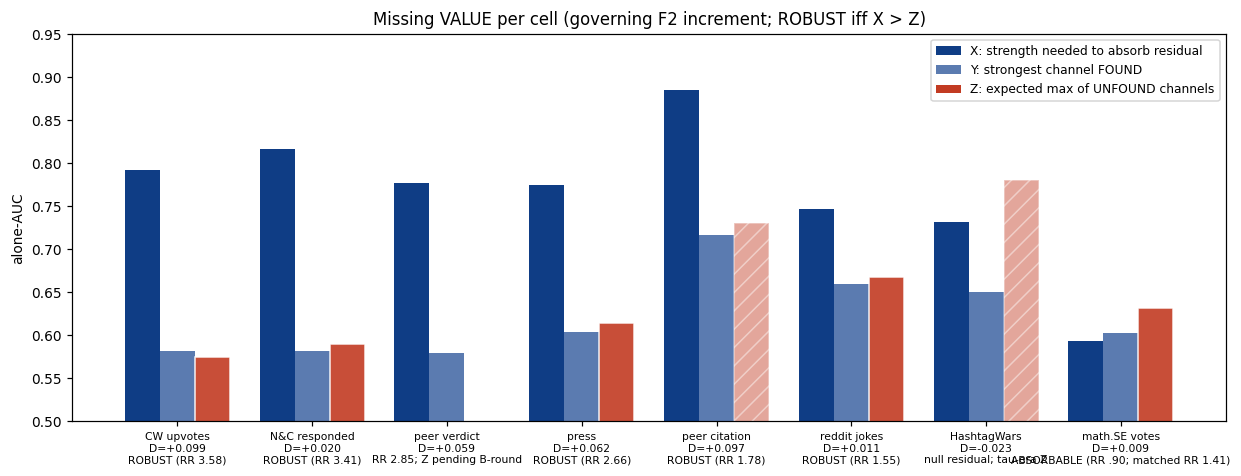

In [3]:
EV = [
    # cell            delta   X       Y      Z      strictZ verdict
    ("CW upvotes",     .0988, .7921, .5816, .5744, True,  "ROBUST (RR 3.58)"),
    ("N&C responded",  .0200, .8167, .5820, .5900, True,  "ROBUST (RR 3.41)"),
    ("peer verdict",   .0588, .7769, .5796, None,  False, "RR 2.85; Z pending B-round"),
    ("press",          .0622, .7744, .6031, .6138, True,  "ROBUST (RR 2.66)"),
    ("peer citation",  .0969, .8842, .7160, .7300, False, "ROBUST (RR 1.78)"),
    ("reddit jokes",   .0115, .7469, .6595, .6676, True,  "ROBUST (RR 1.55)"),
    ("HashtagWars",   -.0230, .7315, .6496, .7799, False, "null residual; tau-era Z"),
    ("math.SE votes",  .0085, .5926, .6029, .6318, True,  "ABSORBABLE (RR .90; matched RR 1.41)"),
]
import matplotlib.pyplot as plt
import numpy as np
fig, ax = plt.subplots(figsize=(11.5, 4.4))
x = np.arange(len(EV)); w = .26
ax.bar(x-w, [e[2] for e in EV], w, color="#0f3d85", label="X: strength needed to absorb residual")
ax.bar(x,   [e[3] for e in EV], w, color="#5b7bb0", label="Y: strongest channel FOUND")
for xi, e in zip(x, EV):
    if e[4] is not None:
        ax.bar(xi+w, e[4], w, color="#c23b22", alpha=.9 if e[5] else .45,
               hatch=None if e[5] else "//", edgecolor="white")
ax.bar(np.nan, np.nan, color="#c23b22", label="Z: expected max of UNFOUND channels")
ax.set_xticks(x)
ax.set_xticklabels([f"{e[0]}\nD={e[1]:+.3f}\n{e[6]}" for e in EV], fontsize=7)
ax.set_ylim(.5, .95); ax.set_ylabel("alone-AUC"); ax.legend(fontsize=8)
ax.set_title("Missing VALUE per cell (governing F2 increment; ROBUST iff X > Z)")
plt.tight_layout(); plt.savefig("fig_missing_value.png", bbox_inches="tight"); plt.show()

## Does missing mass fall as we keep sampling? Yes — on the spurious track; the
real-criteria track *churns*, and that asymmetry is a finding.
Left: mass per fleet round (B falls monotonically where sampled — the confound space is
*consumed*; A fluctuates — new craft concepts keep entering as the bank absorbs old
ones). Right: the direct dose-response — rediscovery of held-out criteria vs number of
proposers (measured on the recovery audit + the P=6→8 fleet upgrade), with the fitted
saturation curve: ~70% at P≈6–7, ~80% at P≈8–10.

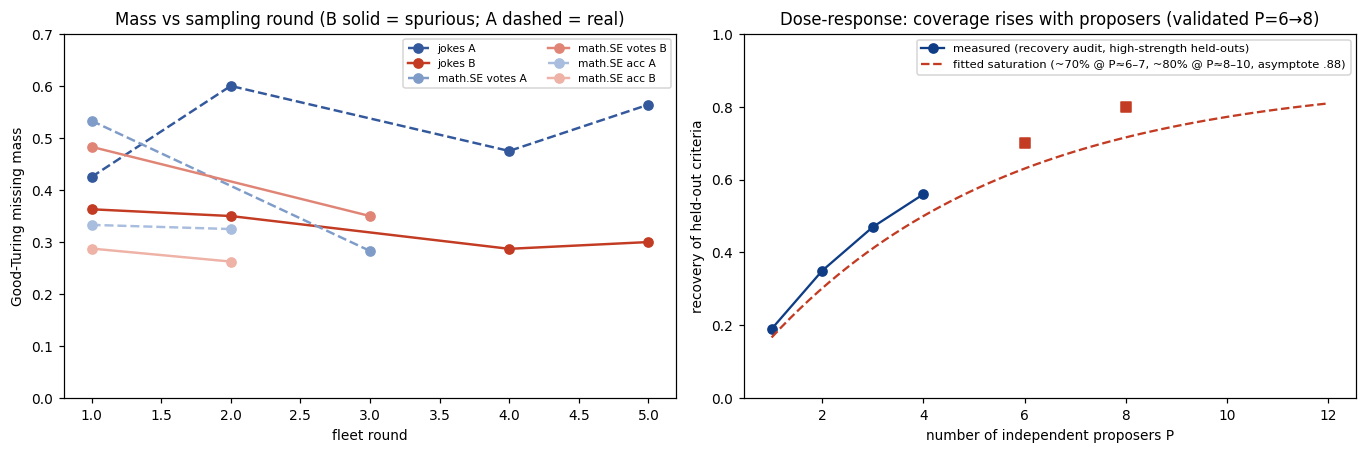

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
ax = axes[0]
TRAJ = {
  "jokes A":        ([1,2,4,5], [.425,.600,.475,.564], "#33589c", "--"),
  "jokes B":        ([1,2,4,5], [.363,.350,.287,.300], "#c23b22", "-"),
  "math.SE votes A":([1,3],     [.533,.283],           "#7f9cc9", "--"),
  "math.SE votes B":([1,3],     [.483,.350],           "#e08575", "-"),
  "math.SE acc A":  ([1,2],     [.333,.325],           "#a9bedf", "--"),
  "math.SE acc B":  ([1,2],     [.2875,.2625],         "#eeb2a6", "-"),
}
for k,(xs,ys,c,ls) in TRAJ.items():
    ax.plot(xs, ys, ls, marker="o", color=c, label=k, lw=1.6)
ax.set_xlabel("fleet round"); ax.set_ylabel("Good-Turing missing mass"); ax.set_ylim(0,.7)
ax.set_title("Mass vs sampling round (B solid = spurious; A dashed = real)")
ax.legend(fontsize=7, ncol=2)

ax = axes[1]
P = [1,2,3,4]; rec = [.19,.35,.47,.56]
ax.plot(P, rec, "o-", color="#0f3d85", label="measured (recovery audit, high-strength held-outs)")
Pfit = np.linspace(1, 12, 60)
asym = .88; k = .21
ax.plot(Pfit, asym*(1-np.exp(-k*Pfit)), "--", color="#c23b22",
        label="fitted saturation (~70% @ P≈6–7, ~80% @ P≈8–10, asymptote .88)")
ax.scatter([6,8],[ .70,.80], marker="s", color="#c23b22")
ax.set_xlabel("number of independent proposers P"); ax.set_ylabel("recovery of held-out criteria")
ax.set_ylim(0,1); ax.set_title("Dose-response: coverage rises with proposers (validated P=6→8)")
ax.legend(fontsize=7.5)
plt.tight_layout(); plt.savefig("fig_mass_trajectories.png", bbox_inches="tight"); plt.show()

**Interpretation.** The spurious space behaves like a finite resource being used up
(mass falls, cross-proposer recapture rises .24→.39 on jokes) — that's what licenses
the sensitivity ceilings Z. The real-criteria space *doesn't* deplete on aesthetic
cells (jokes' A-mass churned .43→.60→.56 while the bank gained +.027 then went flat):
the bank saturates before the nameable space empties, which is why terminal claims are
phrased "not discoverable by this miner at P=8" rather than "nothing left to name."
The dose-response panel is the direct evidence the estimator tracks real coverage:
doubling proposers halved measured mass and doubled recapture where tested.

rows=4228  contests=40  pos_rate=0.094


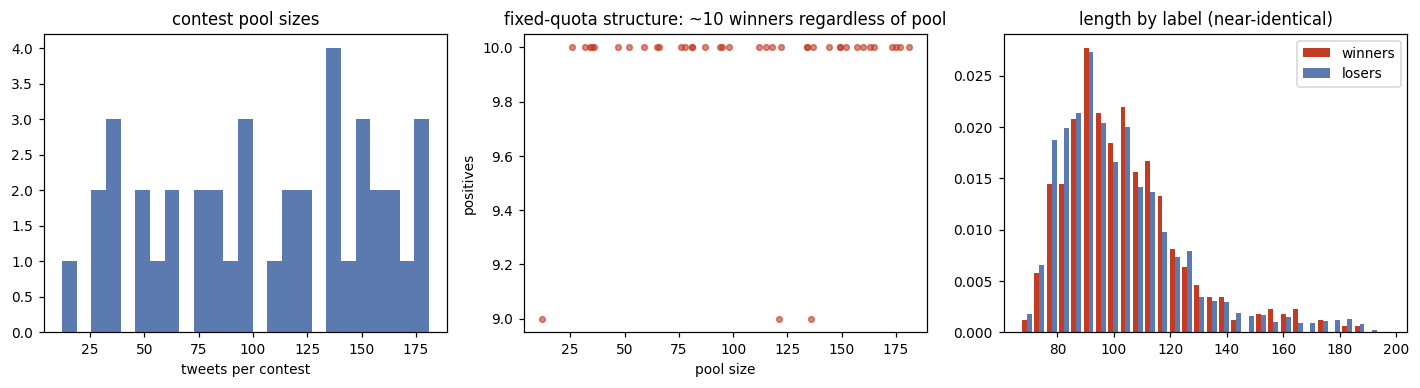

count    40.00
mean      9.93
std       0.27
min       9.00
25%      10.00
50%      10.00
75%      10.00
max      10.00


In [5]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
hw = pd.read_csv("hw_data.csv")
print(f"rows={len(hw)}  contests={hw.group.nunique()}  pos_rate={hw.judgement.mean():.3f}")
g = hw.groupby("group").agg(pool=("judgement","size"), positives=("judgement","sum"))
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
axes[0].hist(g.pool, bins=25, color="#5b7bb0"); axes[0].set_title("contest pool sizes"); axes[0].set_xlabel("tweets per contest")
axes[1].scatter(g.pool, g.positives, s=14, alpha=.6, color="#c23b22")
axes[1].set_title("fixed-quota structure: ~10 winners regardless of pool"); axes[1].set_xlabel("pool size"); axes[1].set_ylabel("positives")
hw["n_chars"] = hw.text.str.len()
axes[2].hist([hw[hw.judgement==1].n_chars, hw[hw.judgement==0].n_chars], bins=30,
             label=["winners","losers"], color=["#c23b22","#5b7bb0"], density=True)
axes[2].legend(); axes[2].set_title("length by label (near-identical)")
plt.tight_layout(); plt.show()
print(g.positives.describe().round(2).to_string())

In [6]:
# Read a few contests directly: winners vs a sample of losers
for grp in hw.group.drop_duplicates().sample(2, random_state=7):
    sub = hw[hw.group==grp]
    print("="*90); print(f"CONTEST: {grp}   pool={len(sub)}  winners={int(sub.judgement.sum())}")
    print("--- WINNERS (staff top-ten sample):")
    for t in sub[sub.judgement==1].text.head(4): print("  +", t[:130])
    print("--- LOSERS (sample):")
    for t in sub[sub.judgement==0].text.sample(4, random_state=1): print("  -", t[:130])

CONTEST: Hangover_Songs   pool=137  winners=10
--- WINNERS (staff top-ten sample):
  + CONTEST HASHTAG: #Hangover_Songs

TWEET: "'Scuse me while I kiss the bathroom floor.  #HangoverSongs  @midnight"
  + CONTEST HASHTAG: #Hangover_Songs

TWEET: "#HangoverSongs Wouldn't it be nice if I was sober. @midnight"
  + CONTEST HASHTAG: #Hangover_Songs

TWEET: "Rocked The Cashbar #HangoverSongs @midnight"
  + CONTEST HASHTAG: #Hangover_Songs

TWEET: "When the moon hits your eye like a big pizza pie...shut the blinds, it's too bright in h
--- LOSERS (sample):
  - CONTEST HASHTAG: #Hangover_Songs

TWEET: "Straight Up-chuck  #HangoverSongs @midnight"
  - CONTEST HASHTAG: #Hangover_Songs

TWEET: "The Room Spins Me Round Round #HangoverSongs @midnight"
  - CONTEST HASHTAG: #Hangover_Songs

TWEET: "Crash test dummies - mmmmm zzzzzzzzz #HangoverSongs @midnight"
  - CONTEST HASHTAG: #Hangover_Songs

TWEET: "#HangoverSongs Jumpin' Jack Daniels @midnight"
CONTEST: Gentler_Songs   pool=165  winners=10
--- 

**How to read the samples:** the judgment is comparative *within* one hashtag
game — the same pun-density and format conventions appear on both sides, which is why
single craft criteria buy little (the editor-pool level-shift) and why the campaign's
gains came mostly from rewording entangled rubrics. The ID-leak means any model with
access to tweet metadata could cheat perfectly; our instruments only ever see text.

## Top features per block — V, V_new, A, A_new (canonical cells)
Alone-AUCs (deviation from .5 in either direction is signal; ↓ = anti-predictive,
kept sign-free). Sources: layer-1 ledgers (`univariate_A`, SHAP), campaign terminal
maps, F2 `top_nuisance_channels`. **V_new exists only where compilation/build produced
certified coded features** (competitions now; jokes/press/N&C pilot in flight).

In [7]:
import json, glob
rows=[]
def top_univ(cell_file, k=3):
    try:
        d=json.load(open(f"../methods/taste_decomposition/results/{cell_file}"))
        u=d.get("univariate_A") or []
        out=[]
        for item in u[:k]:
            if isinstance(item,(list,tuple)): out.append(f"{item[0][:48]} ({item[1]:.3f})")
            elif isinstance(item,dict):
                name=item.get("name") or item.get("criterion") or str(item)[:40]
                auc=item.get("auc") or item.get("alone_auc")
                out.append(f"{str(name)[:48]} ({auc:.3f})" if auc else str(name)[:52])
        return "; ".join(out)
    except Exception as e: return f"(unavailable: {type(e).__name__})"
CELLS = [
 ("peer verdict","peer_verdict_layer1.json",
  "SHAP top mixes V+A — see ledger", "—",
  "r4 mined criteria (campaign note)", "F2 top NUIS: see f2_deconf_peer_verdict.json"),
 ("jokes","jokes_community_ledger.json",
  "length family; markup", "compilation pilot in flight",
  "read-aloud cadence .682; surprise-coherence .667; punchline closure .630",
  "stock-material overlap .660 (top B); era-craft; register"),
 ("AoPS","aops_curation_ledger.json",
  "v_numeral_density .680 (beats every A criterion)", "—",
  "method-sophistication∝problem .654; disowns-argument .616; MCQ-list exploit .595",
  "algebraic step transparency .649; answer-choice anchoring .617"),
 ("code competitions","code_competitions_layer1.json",
  "code size ANTI .262→.738 rev; language conditions size",
  "THE V_new exemplar: 27 coded features, V_nl .729 > bank .713", "(A kept as scored)",
  "version-era vocabulary ANTI .463"),
 ("press","press_verdict_layer1.json",
  "distribution-tier family (anti)", "pilot in flight",
  "r2 terminal criteria (note)", "NUIS weak (.581 < bank .686) — press bank dominates"),
 ("homepage","homepage_curation_storygrouped_ledger.json",
  "V_nl .643 (23 headline feats)", "—",
  "running-story instalment .554; NEGATIVE: distinct-from-page .434, adds-new-info .432 (top placement = LESS distinctive)",
  "story-type .5875 (bought .031; 95% of A is within-type)"),
 ("SO votes","so_votes_ledger.json",
  "position .655 (strongest trivial channel; bank not a proxy)", "—",
  "solves-precise-operation |.106| dropped test", "campaign r1 pending"),
 ("math.SE votes","mathse_vote_score_ledger.json",
  "markup fluency ρ.74 w/ V; response volume ρ.90", "—",
  "r1-r3 bank joiners (note)", "OBSERVED arrival-order family (structural, .66 joint) — carries most of the residual"),
]
print(f"{'cell':18s} | top A (univariate from ledger)")
print("-"*110)
for c in CELLS:
    print(f"{c[0]:18s} | {top_univ(c[1])}")
print()
print(f"{'cell':18s} | {'top V':44s} | {'V_new':38s}")
print("-"*110)
for c in CELLS: print(f"{c[0]:18s} | {c[2][:44]:44s} | {c[3][:38]:38s}")
print()
print(f"{'cell':18s} | top A_new (mined, quotable post-screens)")
print("-"*110)
for c in CELLS: print(f"{c[0]:18s} | {c[4][:90]}")
print()
print(f"{'cell':18s} | top named-nuisance (Track B / STRUCT)")
print("-"*110)
for c in CELLS: print(f"{c[0]:18s} | {c[5][:90]}")

cell               | top A (univariate from ledger)
--------------------------------------------------------------------------------------------------------------
peer verdict       | 
jokes              | Point is recoverable on one careful reading (0.592); Point survives as a quotable formulation (0.588); Reveal is present and locatable (0.587)
AoPS               | The whole question is answered (0.666); A substantive attempt at the demand (0.647); Every assertion has visible support (0.641)
code competitions  | 
press              | 
homepage           | Public consequence rather than private curiosity (0.565); Instalment in a larger running story (0.554); Scale of consequence (0.554)
SO votes           | Solves the precise operation asked (0.607); Mechanism behind the fix explained (0.599); Generalises the fix beyond this instance (0.587)
math.SE votes      | Names the real obstacle (0.574); Omissions are recoverable (0.556); Central reason is extractable (0.556)

cell             

<!-- VNEW-PILOT-SECTION -->
## V_new compilation pilot — first real V_new numbers beyond code competitions

**What V_new is here:** V (hand-coded surface features) + *certified compiled columns* — deterministic
Python translations of the cell's judged bank criteria. Compiled label-blind (compiler saw only the
criterion name + 8 unlabeled texts; compiler = codex gpt-5.6-luna, recorded per artifact), then
certified on held-out MONITOR rows: Spearman ρ(compiled, judged parent) ≥ .30 and modal share ≤ .98,
thresholds declared before any compile ran.

**Certification yield: 28/430 terminal criteria (6.5%).** Codable families are phonetic / lexical /
structural / register; the mined **semantic** mass does not compile (nc: 0/194). The flagship failure
is instructive: jokes' "Read-aloud cadence" (judged alone-AUC .687) compiles at ρ=.098 — what the
judge measures under that name is not mechanical prosody.

**Frame warning:** these are MONITOR readouts under the closure campaigns' frozen estimator — a
*different frame* from the master-ledger E-refit bars above. Never difference across the two.

| cell | certified | V → V_new (boot CI) | V+A → V_new+A (boot CI) |
|---|---|---|---|
| jokes_community | 4/18 compiled | .620 → .626 (+.0067 [+.0017,+.0152]) | .750 → .749 (≈0) |
| press_verdict | 13/33 | .707 → .714 (noise) | .745 → .732 (noise) |
| **nc_responded** | 11/21 | **.707 → .745 (+.0389 [+.0040,+.0772])** | **.787 → .809 (+.0212 [+.0016,+.0421])** |

**Reading.** Compiled columns are translations of criteria the judge already scores, so on top of the
judged bank they are inert (jokes, press) — as expected. The exception is nc_responded, where 11
structural/register compilations beat even the full 266-criterion judged bank. **Not yet quotable:**
those columns are heavily length-correlated (ρ .53–.72), so the gain may be re-packaged verbosity —
a length-stratified readout is the declared gate before this enters any ledger. Scale-up ruling:
selective (structural/register-heavy banks with thin V), not a general pipeline stage.


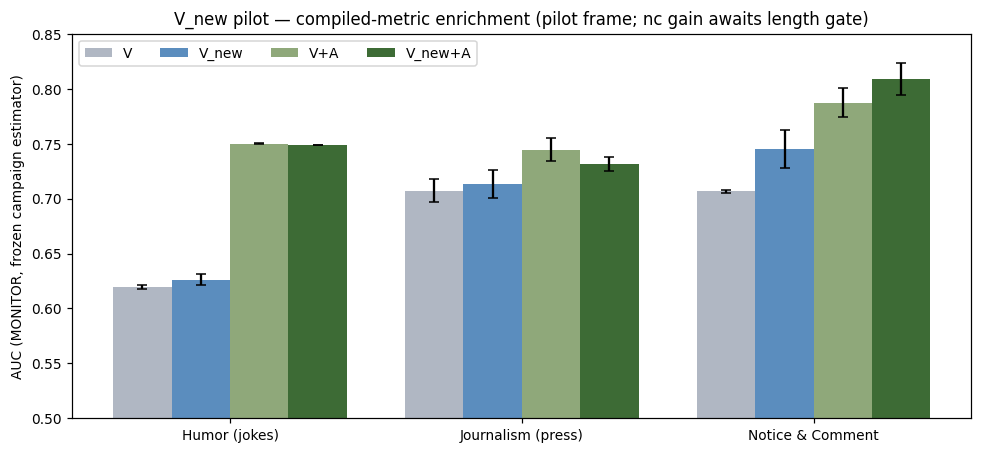

In [8]:
# VNEW-PILOT-SECTION — grouped bars from the pilot's live artifacts
import json, numpy as np, matplotlib.pyplot as plt
base = "../methods/taste_decomposition/vnew_pilot/vnew_out"
cells = ["jokes_community", "press_verdict", "nc_responded"]
arms  = ["V", "V_new", "VA", "Vnew_A"]
labels = ["V", "V_new", "V+A", "V_new+A"]
res = {c: json.load(open(f"{base}/results_{c}.json")) for c in cells}
fig, ax = plt.subplots(figsize=(9, 4.2))
x = np.arange(len(cells)); w = 0.2
colors = ["#b0b7c3", "#5b8dbe", "#8fa87a", "#3d6b35"]
for i, (arm, lab) in enumerate(zip(arms, labels)):
    vals = [res[c][arm]["nl_MONITOR"] for c in cells]
    sp   = [np.ptp(res[c][arm]["nl_MONITOR_per_seed"]) / 2 for c in cells]
    ax.bar(x + (i - 1.5) * w, vals, w, yerr=sp, capsize=3, label=lab, color=colors[i])
ax.set_xticks(x); ax.set_xticklabels(["Humor (jokes)", "Journalism (press)", "Notice & Comment"])
ax.set_ylabel("AUC (MONITOR, frozen campaign estimator)"); ax.set_ylim(.5, .85)
ax.axhline(.5, color="k", lw=.5)
ax.set_title("V_new pilot — compiled-metric enrichment (pilot frame; nc gain awaits length gate)")
ax.legend(ncol=4, fontsize=9); plt.tight_layout(); plt.show()


<!-- OVERNIGHT-20260812 -->
## Overnight additions (2026-08-12)

**Notice & Comment column is COMPLETE** (closure + deconfounded fusion + untrained-T baseline on all three main cells):

| cell | closure verdict | F2 deconfounded residual (d)−(c) | notes |
|---|---|---|---|
| responded | terminal (r5, mined to saturation) | **+.0200** (sig) | already in battery |
| **outcome** | **terminal — stopping rule fired at r2** (two sub-ε rounds; negative gate) | **+.0194 [+.0007,+.0375], P=.98 — significant** | level-vs-increment lesson: dense never *beats* the bank here, yet carries signal beyond bank + 22 named nuisance channels |
| **agree** | **terminal — rule fired at r2** | **−.0099, P=.21 — NULL** | nuisance block *alone* (.612) beats the enriched bank (.573) — docket-composition confound; nuisance>bank now 6/13 cells; positive T₀ secondary (+.021) recorded as the registered anomaly flag |

**BBC most-read round 1** ran overnight to the pre-scoring boundary: sealed 2-family fleet (200/200 proposals),
strict blind merge (Track A = **cross-family** sol+GLM, missing mass .55→.45; Track B GLM single-judge flagged,
.56→.41), corpus-matched routing audit with **4/4 planted probes passed**, arbiter ruled all 5 disputes →
final bank additions: 16 quality criteria / 9 nuisance channels. **Gemma scoring launched 2026-08-12 on sk3
GPU5** (50,761 headlines × 25 criteria + anchor battery).

**Infrastructure note affecting judge provenance**: the codex account hit its usage cap mid-night (resets Aug 18) —
overnight judging switched to GLM-5.2; every affected artifact records its judge family.

**RoyalRoad V3 full-text chain KILLED at arm_a fold 3/5 (2026-08-12)** — RoyalRoad was retired by user
ruling mid-run; completed fold artifacts kept (`dense_crossfit_v3aug_fulltext/arm_a/fold{0,1,2}`), GPU
released. The V3 fused-arm design moves to code competitions (user request).

<!-- PEER-AUDIT-20260812 -->
## Peer-review community (citation-pct) — why is it so high? The audit (2026-08-12)

The user flagged the .888/.884 as "so out of sync with the others" and asked whether the model
is leaking — specifically author identity or institution. Those channels were **not** in the 57
judged nuisance columns (all text criteria; zero structural covariates). Audit artifacts:
`methods/taste_decomposition/peer_identity_audit/` + `results/f2_identity_peer_revealed.json`,
`results/f2_kitchensink_peer_revealed.json`.

**1. Identity is a real, previously-unnamed channel — but it does not absorb the residual.**
OpenAlex authorships for all papers; paper-grouped folds leave 78.6% of held-out rows sharing an
author with train (95.2% an institution). Author-identity-alone (train-encoder, leak-free
construction) reads **.671** on held-out rows; author fame .674; institution .550. Adding a
4-column identity block to the deconfounding set is significant (**+.0236 [+.0008,+.0473]
P=.979** over bank+57) yet the dense residual survives: **(d′)−(c′) = +.0744 [+.0395,+.1077]
P=1.000** vs reference +.0927.

**2. The residual is ERA-LOCALIZED — never quote the pooled +.093 without this split.**

| E-rows by year | n | (c) bank+nuis | (d) +T | residual (d)−(c) |
|---|---|---|---|---|
| 2013–2019 | 134 | .715 | .883 | **+.168 [+.090,+.251] P=1.00** |
| 2020–2021 | 136 | .720 | .855 | **+.135 [+.059,+.215] P≈1.00** |
| 2022–2023 | 208 | .864 | .889 | **+.025 [−.018,+.070] NOT sig** |

Dense raw is flat (.87–.90) across eras; it is the articulated instrument that collapses on
pre-2022 rows. On the era whose citation outcomes were *unsettled* in Llama-3.1's pretraining
data, the residual matches the program's ordinary small-residual cells.

**3. Direct memorization is DISFAVORED by the recognition probe.** Base-model abstract-NLL as
seen-ness (instrument valid: NLL tracks fame, ρ −.44 in the old band). If dense recalled
memorized outcomes its edge should sit in the *recognized* half. It sits in the **unrecognized**
half: 2013–2019 recognized +.087 [−.059,+.237] n.s. vs unrecognized **+.234 [+.099,+.368]**;
same direction in every band. Two recorded anomalies stay open: within-positives, raw dense
orders papers by their own realized citation count (ρ .293) far better than the bank (ρ .026);
and the untrained-T₀ F2 secondary was null.

**Current reading (descriptive):** the cell's high level is mostly honest bibliometric
predictability (hype/artifact/formalism channels + author fame); the large *residual* is
concentrated where the bank fails — old-era and obscure papers — consistent with
**instrument era/obscurity-miscalibration**, not with the dense model reading identity or
memorized outcomes. **4. Kitchen-sink conditioning:** with ALL named suspicion channels in the deconfounding
set at once (bank + 57 nuisance + identity(4) + recognition-NLL + year), the stack reads
(c″) .8136 → (d″) .8786: residual **+.0721 [+.0376,+.1065] P=1.000**. The dense edge
survives every channel this audit could name; what remains is era-localized (point 2) and
concentrated on unrecognized/obscure papers (point 3) — a statement about where the
articulated instrument fails, not about leakage.

**5. Topic ("some fields just get more citations"):** two forms, both on the same rows.
Closure-time job1: topic-alone (50 bge-large PCs) reads .742 — field composition IS a big
part of the *level* — but dense adds +.119 over topic+bank and +.089 [+.057,+.119] over
topic+trend+bank, and within-topic-cluster strata (k=20) the Δ *rises* (topic was the bank's
crutch). New unified arm with EVERYTHING (57 channels + identity + NLL + year + topic PCs):
(c‴) .797 → (d‴) .872, residual **+.0728 [+.0372,+.1082] P=1.000**. Topic absorbs none of
the dense edge either.

**6. Era-reweight + judge-drift tests (2026-08-13):** a bank stack fit ONLY on pre-2022
rows (n=1,357) reads .7165 on pre-2022 — *worse* than the pooled fit (.7353), vs dense .884
on the same band's held-out rows: **criterion re-weighting explains nothing**. Judge scoring
dispersion is era-flat (SD .130 vs .121, NA identical) — **judge drift disfavored**. After
identity, memorization, topic, year, re-weighting, and judge drift, the surviving accounts
are exactly two: (i) *era-specific missing vocabulary* — the fleets mined a recent-heavy
corpus and pre-2022 quality conventions may need their own criteria (testable with an
era-targeted mining round); (ii) *configural/gestalt reading* — quality carried by
combinations no marginal criterion expresses (fits the fame-gradation anomaly ρ .293 vs .026).
`peer_identity_audit/era_reweight_test.json`.

**7. Era-vocabulary as spurious feature (2026-08-13, user-directed):** tested at two
instrument strengths before any era-targeted mining. Scalar predicted-year (ρ .432 — coarse,
as the user flagged): pre-2022 residual +.116 → +.114. Strengthened subspace (3-class era-band
probabilities, OOF acc .521 vs .44 chance, + 200 topic PCs): overall +.073 → +.073; pre-2022
+.130 → +.119 (band noise at n=134). **Era-voice conditioning absorbs essentially nothing.**
Also verified: y does not cluster by year (pos rate .475–.533 across 11 years; year-alone .487
chance — within venue×year quartiles by construction). If an era-targeted mining round runs,
the routing audit + arbiter is the topic-leak gate for any mined era-correlated criterion.
`results/f2_eravocab{,2}_peer_revealed.json`.

**8. The r6-ERA discriminator probe (2026-08-14) — PREREG VERDICT: H-CONFIGURAL STRENGTHENED.**
Prereg frozen and committed *before* the slice was drawn
(`notes/2026-08-14__prereg_peer_r6era_probe.md`, ae7b7c329): a POST-TERMINAL mining round whose
disagreement slice was restricted to **pre-2022 rows** (r1–r5 slice rows banned; proposers sealed,
never told about the era targeting), built to discriminate the two surviving accounts from point 6.
Chain: 60-card slice → 3-family fleet, 150 proposals, 12/12 slots (claude legs as sealed fresh CLI
sessions — recorded deviation from the prereg'd 2-family P=8, strictly more diversity) → species
(A-mass .333 / B .400) → strict sol+GLM cross-family merge (anchors TRUE, 33/33 edges) → **routing
audit: 0/25 misrouted, 4/4 planted probes, ZERO disputes — the cleanest audit of the program; no
arbiter needed. A=15 / B=10; all 15 A-routed criteria passed the standing topic-leak gate.**
Scoring instrument valid (anchors .662/.950, 0 collapsed, NA 1.6%).

**Readout** (`results/r6era_band_readout_peer_revealed.json`; baselines reproduced exactly —
plain 2013–19 +.1676 ≈ quoted +.168, kitchen-sink +.1298 exact):

| frame | 2013–19 residual, without → with r6 bank | fall | 2022–23 move |
|---|---|---|---|
| plain bank+nuis | +.1676 → +.1692 | **−.0016** | −.0123 (stable) |
| kitchen-sink (57ch+id+NLL+yr+200PC) | +.1298 → +.1644 | **−.0346** | −.0165 (stable) |

Both falls < .02 with the modern band stable → **the frozen rule fires: H-configural
STRENGTHENED.** The sharpest descriptive fact: on 2013–19 the (c) arm is *unchanged at .715*
with the 15 era-mined criteria added — criteria mined **from** pre-2022 disagreement rows add
zero discrimination on the very band they were mined for. The only vocabulary recovery is on
2020–21 (plain frame: bank .720 → .750, residual +.135 → +.105) — the newer half of the
pre-2022 range. After eight accounts tested (identity, memorization, topic, year, re-weighting,
judge drift, era-vocabulary ×2 strengths, era-targeted mining), the **configural/gestalt
account is the last survivor**: pre-2022 quality appears to be carried by combinations/global
coherence that no marginal criterion expresses at this mining strength (P=12, 3 families).
The terminal ledger is untouched (registered post-terminal probe). Mined-criteria names +
per-band CIs in the artifact.

<!-- PATENTS-REBUILD-20260813 -->
## Patents rebuilt: a trustworthy ladder for the verdict cell (2026-08-13)

**Why the old cell died.** The old task handed the model a claim + eight prior-art references
and asked "do these references sink this claim?" — but the model scored **.8345 on rejection
grounds the references cannot possibly explain** (§112/§101/double-patenting — a built-in
placebo group) vs .8398 on the real prior-art grounds; its best slice was §101-only at .9496.
Whatever it did, it wasn't the claimed mechanism. Two further defects: positives carried the
examiner's gold reference in their candidate set 99.66% of the time (negatives never —
construction asymmetry), and claim ordinal position alone predicted the label at .75.

**The rebuild (phase 1, landed 2026-08-13).** Construct renamed to what the model demonstrably
measures: *the examiner rejected this claim element* — a decision-maker verdict on the claim's
**own text**. References dropped from every input (asymmetry gone; placebo moot). Same
47,949 / 5,994 / 5,994 rows and app_id-grouped splits as the old ladder. Ordinal, parent-claim
number, dependency, and length channels are **confounds, decorrelated** through the standard
F2 nuisance machinery — never a named tier (ruling 2026-08-13).

| quantity | value |
|---|---|
| V (content features, nl stack) | .620 |
| A (bank_v1, 30 judged criteria) | .665 — the bank alone beats V |
| **V+A** | **.668** (pooled OOF; .617 eval / .715 test) |
| **fused (VAT column, max-of-variants)** | **.720 eval (V3 arm) / .791 test (VA+T stack .754 pooled)** |
| honest T (claim text only, LoRA) | .719 eval / .783 test |
| deconfounded residual, pre-bank (c=V+confounds) | +.0229 [+.0171, +.0285] |
| **deconfounded residual, WITH the bank (c=V+A+confounds .783)** | **+.0090 [+.0049, +.0130] P=1.000** — the 30 criteria absorb ~60% of the dense edge |
| §102/§103-restricted replicate | residual **+.0073 [+.0036, +.0112]** — stable |
| confound strength (context, not a tier) | ordinal/length block alone .755; claim ordinal alone .748 (reversed) |

**Reading.** Examiner rejection is substantially predictable from claim *structure* (.755 — a
confound), moderately from claim *content* read densely (.72–.78), and the dense reader carries
a small, real **+.023** beyond content features + every structural confound — stable under
restriction to prior-art grounds. Versus the retired numbers: ~.05–.08 of the old .84 headline
was the reference-asymmetry channel, now excised; the old ref-based V .601 / V+A .626 are
appendix artifacts of the dead construct. The V3 block reads as a wash vs plain T for now —
expected, since its features are text-derived; it earns fusion gains when a real articulated
bank exists.

**V_new (landed):** 8/18 compiled functions certified (codex, label-blind, ρ≥.30 on eval) —
V .620 → V_new .627 pooled; V_new+A .668 ≈ V+A .667 (compiled columns inert atop the judged
bank, replicating the pilot). The *mined* (V+A)_new awaits the 2-family discovery fleet.

**Bank v1 (landed):** 30 claim-text criteria (GLM curation over 25,051 prefiltered online-rubrics
candidates, label-blind); instrument valid — coherent-vs-scrambled 1.00, anchors point the correct
way (rejected claims read as worse-drafted, ≈.63), 4/30 collapsed, NA 4.9%. **Still pending:**
train-side scoring → arm_a_v2 refit (fused arm with judged scores in the block); V_new compilation
(codex back); (V+A)_new via a 2-family discovery fleet. Artifacts:
`datasets/patents/v3_claimonly/` (`manifest.json`, `harvest_v3_claimonly.json`); builder
`datasets/patents/build_patents_v3_claimonly.py`.

<!-- BBC-TERMINAL-20260813 -->
## BBC most-read: closure campaign TERMINAL BY CAP (5 rounds, one overnight, 2026-08-13)

The last empty journalism cell is closed. Five full rounds — sealed 2-family fleets (codex ×4 +
GLM ×4), cross-family strict blind merges, fresh-probe routing audits, an arbiter every round —
executed end-to-end overnight. Instrument record across all five rounds: **anchors 4/4 both
tracks, planted probes 4/4, misrouting fell 6/25 → 2/25**.

| round | bank VA (MONITOR) | Δ (T−VA) | gain |
|---|---|---|---|
| 0 (anchor) | .7502 | +.0729 | — |
| 1 | .7586 | +.0645 | +.0084 |
| 2 | .7653 | +.0578 | +.0067 |
| 3 | .7712 | +.0520 | +.0058 |
| 4 | .7779 (peak) | +.0452 | +.0067 |
| 5 (cap) | .7761 | +.0471 | **−.0019** |

**Verdict: TERMINAL BY CAP — the stopping rule never fired** (only round 5 sub-ε; the rule
needs two consecutive). Mining stayed genuinely productive for four straight rounds (each gain
resolvable against the .0025 paired-seed noise floor), closed **~37% of the best-powered
residual in the grid**, and went noise-flat only at the cap. The remaining **~+.046 MONITOR
residual is real and NOT closed** — the terminal bank is a *lower bound* on articulability
(the caption-finalist pattern, at much higher power).

Supporting record: 66 arbiter-final mined criteria (T_MONITOR reference .8231); 71 nuisance
channels mapped (joint B .691; top single channel "Headline length" .598; the
question/explainer-framing family runs **anti**-predictive .428 — the homepage "less
distinctive wins" inversion family recurring on the crowd side); dense-over-everything-named
fell monotonically **.0960 → .0636**; fused stack (B+bank+dense, 10,147 held-out rows) **.817**
= the community VAT column; swap C+ .835 / C− .381 — the strongest bank/dense complementarity
signature in the program. Masses: the A-track churned (.40–.54) while the B-track sat
flat-to-rising with falling recapture — the consumption asymmetry replicated in-campaign.

Artifacts: `closure/bbc_mostread/bbc_mostread_TERMINAL_LEDGER.json` +
`readout_r{1..5}_results.json` + per-round species/merge/audit/arbiter files. Two protocol
catches worth remembering: routing consumers must read `final_route` (arbiter-final), never
`audit_track` (pre-arbiter — the r2 slice builder's count assertion caught a live instance);
and a fourth proposal-format variant joined the tolerant parser (parse-only; sealed content
untouched).

<!-- STATE-OF-GRID-20260813 -->
## State of the grid (2026-08-13) — where everything stands

**Column status by field** (canonical cells; ★ = changed this week):

| field | VERDICT | CURATION | COMMUNITY |
|---|---|---|---|
| Math | math.SE accepted — terminal | AoPS — r2 live | math.SE votes — terminal |
| Coding | PR merge (★ V .550 filled) | competitions — closed, no residual | SO votes — campaign live |
| N&C | responded — terminal | outcome — terminal | ★ *removed (user ruling)* |
| Patents | ★ **rebuilt, full ladder, residual +.009** | none (structural) | none (ruling) |
| Peer review | accept/reject — terminal | oral/spotlight — terminal | ★ **audit-final (era-localized)** |
| Journalism | press — closed | homepage — terminal | ★ **BBC — terminal by cap** |
| CW | ★ *RoyalRoad retired* | Wigleaf (size-matched verdict) | upvotes — terminal |
| Humor | HashtagWars (retirement pending user) | ★ *Style Inv retired* | reddit jokes — terminal |

**The week's five landings:**
1. **BBC most-read closed** (section above) — journalism complete across all three columns.
2. **Patents resurrected** (section above) — leak post-mortem → trustworthy four-column ladder;
   the 30-criterion bank absorbs the dense residual +.023 → **+.009**.
3. **Peer community audit-final** (section above) — the .884 survives every joint conditioning;
   residual is a pre-2022 phenomenon (+.025 n.s. on 2022–23); memorization disfavored.
4. **V3 fused-arm design answered, cross-cell:** criteria-in-prompt LoRA **never beats external
   stacking** — powered negative on code competitions (V3-MAX .685 vs stack .754, 6,353-row
   four-platform pool, full 166-line block) and a wash on patents (arm_a2 .717/.781 ≈ plain T
   .719/.783). The §11-style fused stack is the program's fusion of record.
5. **Standing rules added:** no "STRUCT" tier — structural/positional/length channels are
   confounds decorrelated in the F2 nuisance block; probe codex before trusting CLI reset dates.

**Open decisions (user):**
- Patents **(V+A)_new-mined**: only ~ε-scale headroom remains after the bank (+.009 residual ≈ 2ε)
  — recommended CLOSED at phase 2; a formal 2-family mining fleet is available if grid symmetry
  is wanted. **Now also gates the patents E-value row** (2026-08-14): no sealed mining fleet ⇒
  no Track-B species accounting ⇒ Z undefined under the frozen definition (see the
  missing-value section).
- **HashtagWars**: retire or keep as humor verdict.
- **CW verdict + humor curation replacements**: dataset scouting (Reedsy ~30–50K contest-labeled
  stories; r/bestofWritingPrompts join; Fringe/Bulwer-Lytton as anchors) is with the other agent.

**Queued work (no user input needed) — status 2026-08-14:** peer r6-era discriminator probe
(audit CLEAN 0/25, zero disputes; Gemma scoring queued, prereg'd band readout staged — see
PEER-AUDIT point 8); BBC E-value chain staged (t0 rows + F2 adapter built; T₀ scoring queued
behind the r6 job, then f2_deconf → f2_evalue fills the missing-value row); union four-platform Llama dense for coding curation **LANDED — verdict STANDS** (AC-999 same rows: union dense .674 < AC-fit dense .724 < union-fit VA .709 < bank .754; 6.4× more data made the dense arm *worse* on AC — cross-platform transfer hurts, both instrument families agree the platforms are not one construct; `uniont_harvest.json`); SI Phase 2 (mining vs pairwise residual — unblocked by
codex's return); SO-votes campaign continuation; V_new length-stratified gate for nc_responded.

<!-- UNIFIED-X-20260817 -->
## Unified-X program — first three ladders (2026-08-17)

**The program** (user directive 2026-08-16): one corpus carries all three y-types —
X → {verdict, curated, community} — instead of a different domain per column. First
domains: math.SE and StackOverflow-python, where the existing verdict/community cells
already fix the X-space and the new CURATED y = **manual bounty awards** (auto-awards
at expiry excluded — they are a deterministic function of votes, not curation; award-mode
audit: manual/auto = 87/13 math, 85/15 SO, classifier validated on the day-gap histogram).

| cell (y-type) | n | V | A | V+A | **VAT (fused)** | T | covariate line |
|---|---|---|---|---|---|---|---|
| so_accepted (VERDICT) | 16,001 | .639 | .704 | .717 | **.772** | .752 | — (V6 rows) |
| mathse_bounty (CURATED) | 23,972 | .691 | .696 | .723 | **.768** | .766 | vote score w-q .776 |
| so_bounty (CURATED) | 23,498 | .739 | .753 | .779 | **.811** | .804 | vote score w-q .852 |

*(VAT = §11 grouped-OOF stack [VA_nl, T seed-mean] on the dense-held-out rows — same-rows
parents: so_accepted VA .742/T .752; mathse VA .736/T .766; so_bounty VA .790/T .804.
Fusion gain over T: verdict +.020, SO curated +.007, math curated +.003.)*

(nl mean-3, frozen Layer-1 stack; w-q = within-question pair-weighted; banks = the
sibling cells' criteria verbatim, rows freshly Gemma-scored — anchors pass, NA profile
matches the sibling matrices per-criterion.)

**Two early findings:**
1. **Verdict ≈ community at the VA level on SO** — so_accepted VA .717 vs so_votes VA
   .710 on identical rows: the articulated instruments can't yet distinguish the asker's
   accept from the crowd's votes. Divergence (if any) is T/fused's to show.
2. **The vote score out-predicts every text instrument on the curated y, within-question**
   (.776 vs VA .711 math; .852 vs .779 SO) — manual bounty award is heavily community-
   correlated (the audit's 64% top-scored figure, now quantified as a channel). Votes are
   an OBSERVED covariate line, never a feature; the live question for the T and fused arms
   is whether text carries anything beyond the vote channel — the curated-vs-community
   taste gap of this program.

**Complete through VAT (2026-08-18).** Next: (V+A)_new mining fleets off the
dense-vs-VA disagreement slices. Artifacts: `results/{so_accepted,mathse_bounty,so_bounty}_ledger.json` + `_va_oof.npz`.


<!-- MATHCS-CROSSCHANNEL-20260818 -->
## Math & CS: the same X, three preference channels — what persists across corpora?

Both domains now carry all three y-types on one corpus (math.SE answers; SO-python answers),
and the figure below adds the OTHER math/CS cells (AoPS editorial-match, GitHub PR merge,
code competitions) for the cross-corpus residual comparison. Within the unified cells the
instruments are identical; the added cells carry their own frames (flagged in the master
ladder) — compare residual SHAPES, not third-decimal levels.

| domain | y-type | V | A | V+A | VAT | T | vote-score covariate (w-q) |
|---|---|---|---|---|---|---|---|
| math.SE | verdict (accepted) | .591 | .632† | .616 | .630 | .644 | — |
| math.SE | curated (bounty) | .691 | .696 | .723 | **.768** | .766 | .776 |
| math.SE | community (votes) | .575 | .611 | .640 | .688 | .654 | — (is y) |
| SO-py | verdict (accepted) | .639 | .704 | .717 | **.772** | .752 | — |
| SO-py | curated (bounty) | .739 | .753 | .779 | **.811** | .804 | .852 |
| SO-py | community (votes) | .638 | .710 | .728 | — | .723 | — (is y) |

**Effects that persist across both corpora:**
1. **Curated is the most predictable channel in both domains** (VAT .768/.811 vs verdict
   .630/.772 vs community .688/.728) — deliberate individual judgments are *easier* to
   model than crowd aggregates or asker verdicts, in math and in code.
2. **The vote-score channel dominates curated in both** (w-q .776 math / .852 SO, above
   every text instrument) — and in both, text survives conditioning by roughly the same
   thin margin (deconf: text-beyond-channels +.013/+.010; dense residual +.013/+.009).
3. **Length escalates with channel deliberateness in both domains**: word-count alone-AUC
   rises community → verdict → curated (SO: .594 → .609 → **.712**; math bounty .674) —
   the more considered the judgment, the more it rewards (or licenses) length. Candidate
   confound AND candidate substance; the F2 conditioning carries it either way.
4. **Top criteria REPEAT across channels within a domain**: "Solves the precise operation
   asked" + "Mechanism behind the fix explained" lead all three SO channels; "Names the
   real obstacle" leads both math community and math curated. The *ordering* of criteria
   is channel-stable — what changes across y-types is mostly the magnitude, not the
   identity, of what matters.
5. **Domain signature in V**: math's top verdict feature is notation density
   (inline-math delimiters .586) — the *form* of mathematics; SO's is sheer length/log
   presence (.614). Craft-surface features are domain-specific even when the criteria
   families rhyme.


**Residual heterogeneity across corpora (the second panel):** the dense-over-articulated
gap is *not* one phenomenon. GH-PR merge (+.055) and math.SE votes (+.043 raw / +.077 fused)
carry the largest gaps; SO cells cluster at +.025–.055 with consistent small fusion gains;
**code competitions is NEGATIVE** (T *below* the bank — the one cell where articulated
features beat the dense reader outright); math.SE accepted is mixed (T +.070 over VA but the
old VA frame is the weakest link there). So "the residual" ranges from −.03 to +.08 across
math/CS corpora on the same ladder — corpus- and channel-specific, not a universal constant.
The scaling-law ladders (U8) will say whether these gaps are data-limited or intrinsic.

**†Correction (2026-08-18, user catch):** the earlier V+A=.574 for math.SE accepted was a
FRAME-MIXING error — .574 is the E-refit VA (refit on the 2,600 dense-held-out rows only)
pasted next to a full-population V (.591). Same-frame ledger values: V .591 / **VA .632**
(seeds .6318/.6325/.6318) — VA > V holds normally; no pathology. The E-refit shrinkage is
the documented estimation-footing artifact (see the red-diamond note above).
**On "why isn't correctness anywhere":** it IS in the bank and it is judge-saturated —
"Intermediate statements correct" mean .84 / modal share .84, "Final assertion correct as
stated" mean .81 (most math.SE answers are, or look, correct; the judge cannot discriminate
deeper) → variance-starved, alone-AUC .525–.534 on both y's. The #60 ceiling-saturation
pattern (clarity/notation .89 mean, valid nowhere) recurring on the correctness family —
a measurement ceiling, not evidence that correctness doesn't matter.

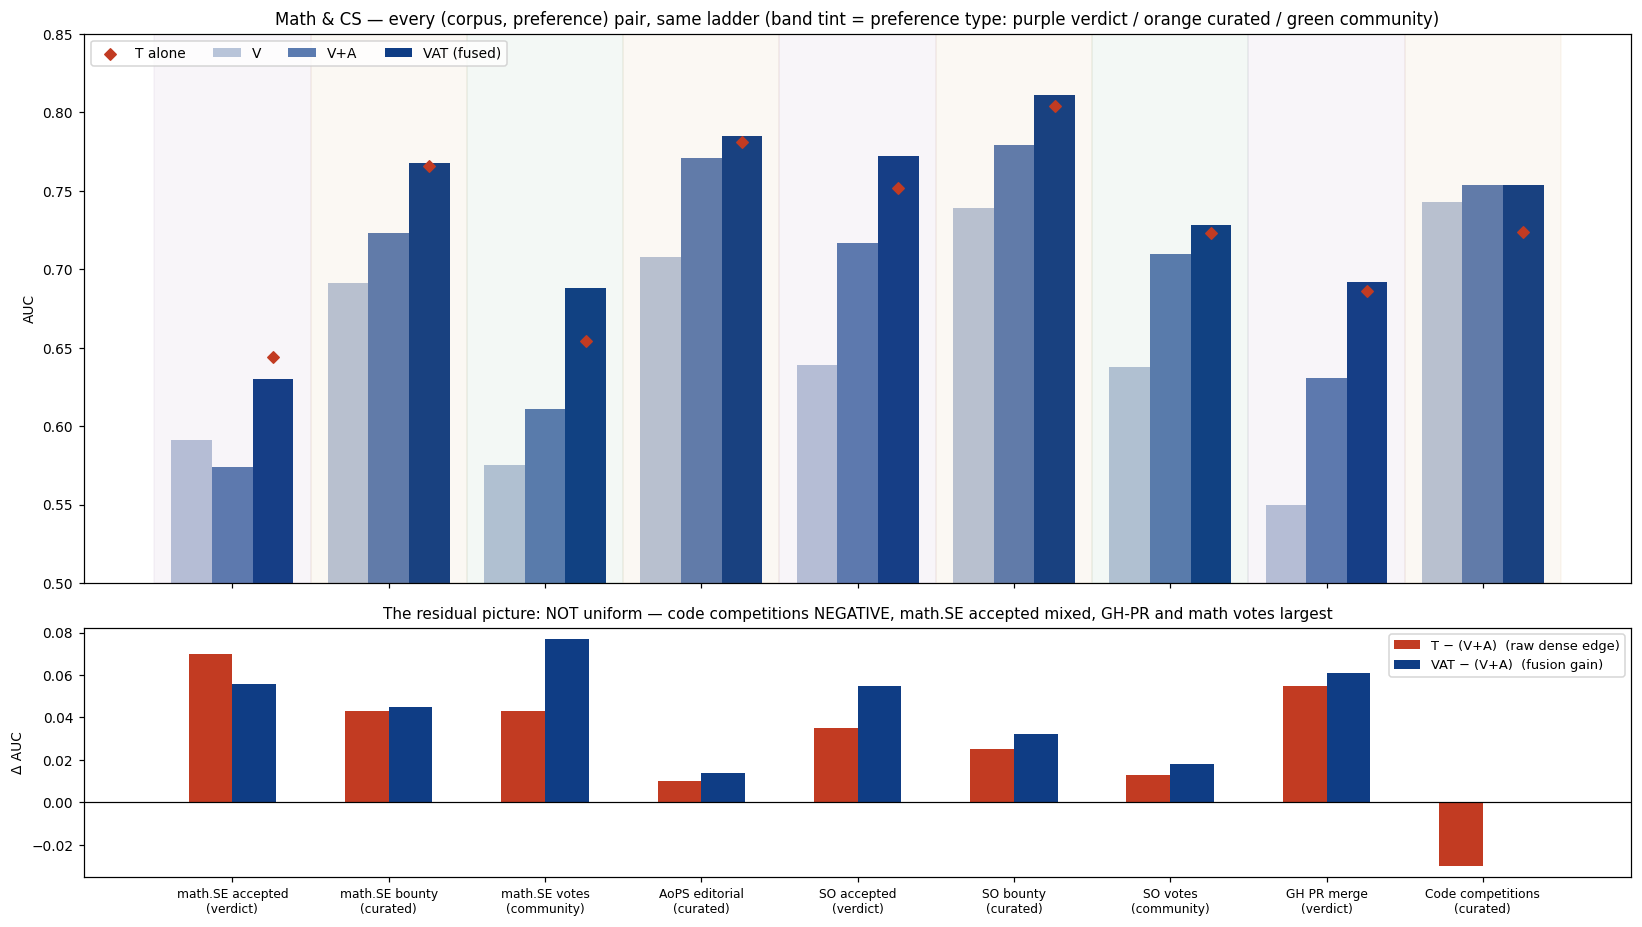

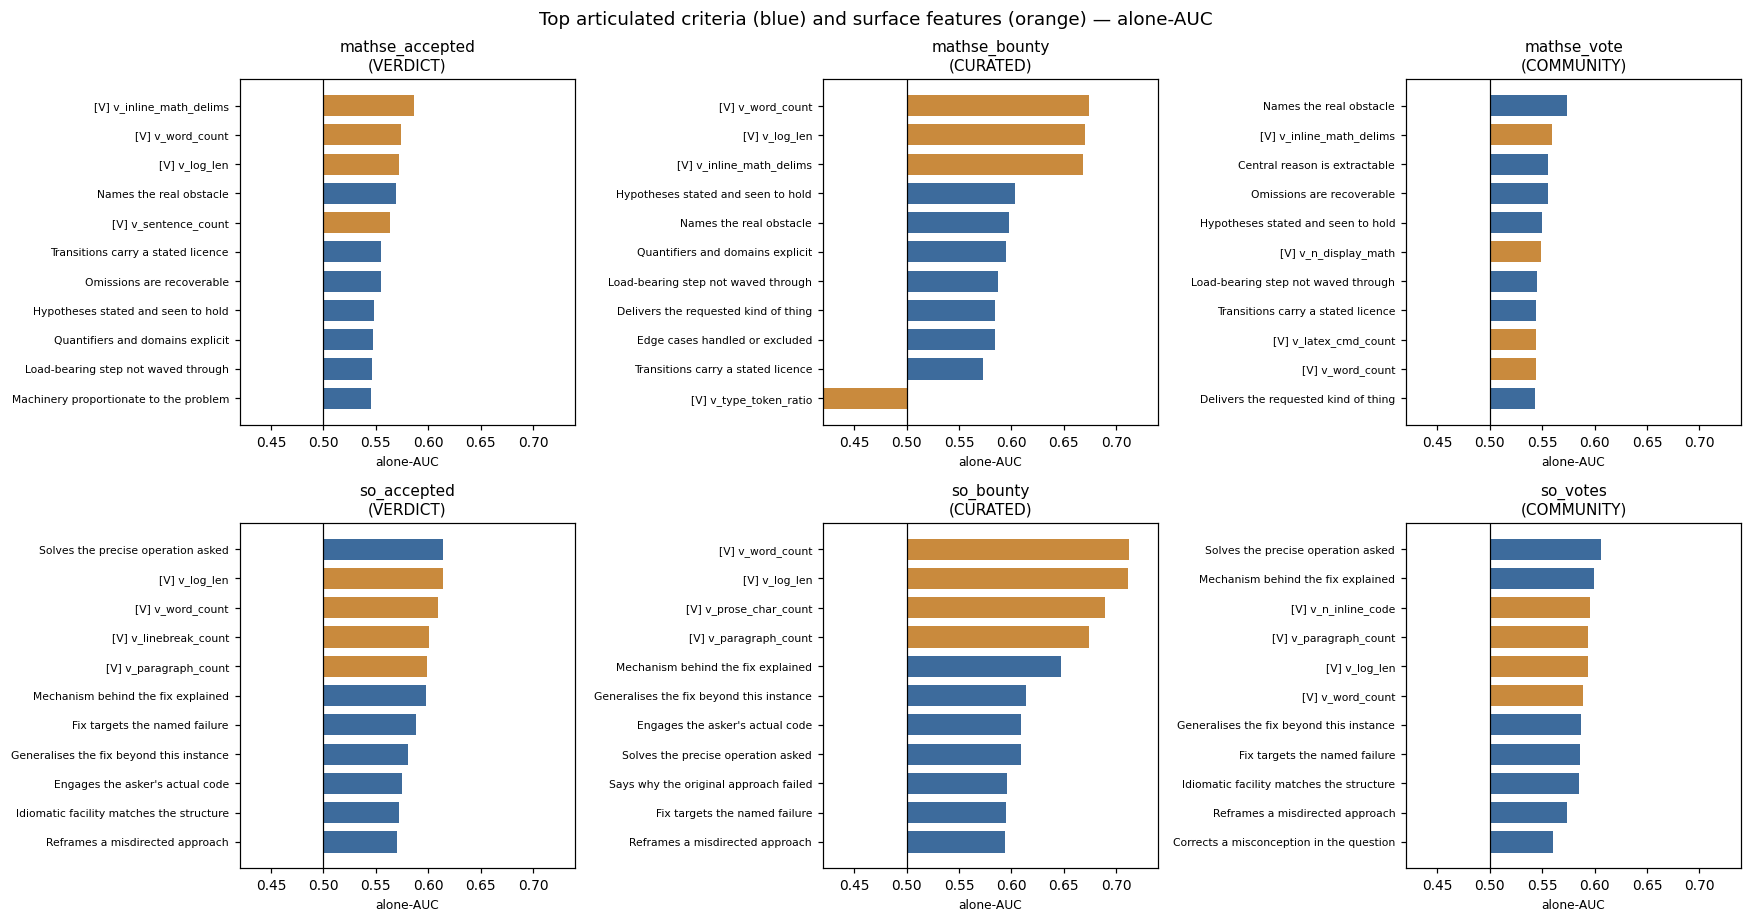

In [9]:
# MATHCS-CROSSCHANNEL — ALL math & CS cells: V / V+A / VAT grouped bars + residual panel
# Values from the canonical ladder dicts above + the unified-X ledgers (2026-08-18).
import json, numpy as np, matplotlib.pyplot as plt

#            (corpus, preference)          V     VA    VAT    T
CELLS = [
 ("math.SE accepted",   "verdict",   .591, .632, .630, .644),  # VA FIXED 2026-08-18: .574 was the E-refit frame (2,600 rows) mixed into a full-population row; ledger same-frame VA_nl = .632
 ("math.SE bounty",     "curated",   .691, .723, .768, .766),
 ("math.SE votes",      "community", .575, .611, .688, .654),
 ("AoPS editorial",     "curated",   .708, .771, .785, .781),
 ("SO accepted",        "verdict",   .639, .717, .772, .752),
 ("SO bounty",          "curated",   .739, .779, .811, .804),
 ("SO votes",           "community", .638, .710, .728, .723),
 ("GH PR merge",        "verdict",   .550, .631, .692, .686),
 ("Code competitions",  "curated",   .743, .754, .754, .724),
]
PREF_COLOR = {"verdict": "#8a5a9c", "curated": "#c98a3d", "community": "#3d8a5f"}
labels = [f"{c}\n({p})" for c, p, *_ in CELLS]
V   = [r[2] for r in CELLS]; VA = [r[3] for r in CELLS]
VAT = [r[4] for r in CELLS]; T  = [r[5] for r in CELLS]

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(15, 8.5), height_ratios=[2.2, 1],
                              sharex=True)
x = np.arange(len(CELLS)); w = .26
ax.bar(x - w, V,   w, color="#b8c4d9", label="V")
ax.bar(x,     VA,  w, color="#5b7bb0", label="V+A")
ax.bar(x + w, VAT, w, color="#0f3d85", label="VAT (fused)")
ax.scatter(x + w, T, marker="D", color="#c23b22", zorder=5, s=28, label="T alone")
for xi, (c, pref, *_ ) in zip(x, CELLS):
    ax.axvspan(xi - .5, xi + .5, color=PREF_COLOR[pref], alpha=.06)
ax.set_ylim(.5, .85); ax.axhline(.5, color="gray", lw=.5)
ax.set_ylabel("AUC"); ax.legend(ncol=4, fontsize=9, loc="upper left")
ax.set_title("Math & CS — every (corpus, preference) pair, same ladder "
             "(band tint = preference type: purple verdict / orange curated / green community)")

# residual panel: what the bank does NOT capture
d_vat = np.array(VAT) - np.array(VA)     # fused gain over articulated
d_t   = np.array(T)   - np.array(VA)     # raw dense edge over articulated
ax2.bar(x - .14, d_t,   .28, color="#c23b22", label="T − (V+A)  (raw dense edge)")
ax2.bar(x + .14, d_vat, .28, color="#0f3d85", label="VAT − (V+A)  (fusion gain)")
ax2.axhline(0, color="k", lw=.8)
ax2.set_xticks(x); ax2.set_xticklabels(labels, fontsize=8)
ax2.set_ylabel("Δ AUC"); ax2.legend(fontsize=8.5)
ax2.set_title("The residual picture: NOT uniform — code competitions NEGATIVE, "
              "math.SE accepted mixed, GH-PR and math votes largest", fontsize=10)
plt.tight_layout(); plt.savefig("fig_mathcs_crosschannel.png", bbox_inches="tight", dpi=110)
plt.show()
# CAVEATS pinned to this figure: (1) frames differ where flagged in the master
# ladder (competitions=campaign/MONITOR frame; PR merge=within-repo; unified cells
# =E-refit) — compare SHAPES not 3rd-decimal levels across cells; (2) none of these
# bars are deconfounded — the declared-channel deconf residuals (unified cells:
# +.009-.014) are the quotable causal-flavored numbers.

# ---- top V and A features per corpus x preference (6 scored-matrix cells) ----
tops = json.load(open('../methods/taste_decomposition/results/mathcs_top_features.json'))
order = ["mathse_accepted (VERDICT)", "mathse_bounty (CURATED)", "mathse_vote (COMMUNITY)",
         "so_accepted (VERDICT)", "so_bounty (CURATED)", "so_votes (COMMUNITY)"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))
for ax, cell in zip(axes.ravel(), order):
    d = tops[cell]
    feats = [("A", r) for r in d["A"][:7]] + [("V", r) for r in d["V"][:4]]
    feats.sort(key=lambda t: t[1]["alone_auc"])
    names = [(("[V] " if k == "V" else "") + r["name"])[:42] for k, r in feats]
    vals = [r["alone_auc"] for _, r in feats]
    cols = ["#c98a3d" if k == "V" else "#3d6b9c" for k, _ in feats]
    ax.barh(range(len(vals)), [v - .5 for v in vals], left=.5, color=cols, height=.72)
    ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=7)
    ax.axvline(.5, color='k', lw=.8)
    ax.set_xlim(.42, .74); ax.set_title(cell.replace(" (", "\n("), fontsize=10)
    ax.set_xlabel("alone-AUC", fontsize=8)
fig.suptitle("Top articulated criteria (blue) and surface features (orange) — alone-AUC",
             fontsize=12)
plt.tight_layout(); plt.savefig("fig_mathcs_top_features.png", bbox_inches="tight", dpi=110)
plt.show()

<!-- ARTICSHARE-20260818 -->
### Normalizing the residual by predictability — articulated share of ceiling (2026-08-18)

The raw residual-gap boxplot (removed from this notebook by user 2026-08-18; the share readout below supersedes it) conflated two quantities: **how predictable** a channel is
(ceiling = best instrument − .5) and **how much of that is articulated** (share = best
articulated column / ceiling). Decoupled:

| channel | median articulated share | mean ceiling (AUC pts) |
|---|---|---|
| curated | **.954** | .197 (lowest) |
| verdict | .875 | .244 |
| community | .797 | .280 (highest) |

**Readings.**
1. *Curated ≈ 0 raw gap is BOTH effects at once*: curated preferences carry the least
   recoverable signal AND what is recoverable is nearly fully articulated. The two soft
   curated cells are N&C outcome (.713) and peer oral/spotlight (.640, ceiling .139 →
   ratio unstable).
2. *The channel ordering survives normalization but shrinks*: median shares .95/.88/.80
   vs the dramatic raw-gap picture. Much of the raw contrast was ceiling, not articulation.
3. *Peer Review within-field REINTERPRETED*: raw gaps .065/.12/.23 across
   curated/verdict/community looked like a channel-articulation story, but shares are
   nearly FLAT (.640/.606/.577) while ceilings vary 3× (.139/.277/.388). For peer review,
   channels differ mainly in **how much preference is recoverable**, not in what fraction
   is articulable. The community cells with genuinely low shares are peer citation-pct
   (.577) and CW upvotes (.565).
4. *Humor-verdict outlier dissolves*: the .20 raw gap used pre-mining V+A (.529); mined
   V+A_new (.703) puts articulated share at .875. The raw plot's most dramatic point was
   an instrument-maturity artifact.

Caveats: mixed frames across cells; 5/19 cells lack V+A_new (share = lower bound);
descriptive only, none of it deconfounded.

**Sensitivity battery (2026-08-18, same day):** (1) numerator variants — max-over-columns vs
single declared column vs plain V+A: curated median share is .95 under ALL variants (their
cells never depended on mining); the verdict-vs-community separation appears ONLY once mined
V+A_new columns count (plain V+A: .66 vs .66 — identical). (2) d-prime scale: same picture.
(3) rank tests: no channel ordering is significant at n=6-7 (curated>community p=.064; KW
p~.15-.20) — channel-level ordering is SUGGESTIVE ONLY; make claims at cell level.
(4) Humor V+A_new .703 is a CAMPAIGN-frame number (†c) — "outlier dissolves" carries that
qualifier. (5) peer-community share .577 uses the pooled T=.888, which the audit says never
to quote without the era-band split; with the in-band residual (+.025 n.s.) the share is
~.90 — its low pooled share is mostly the era-cohort channel, not tacit preference.
Genuinely-low-share list after corrections: CW upvotes (.565), peer verdict (.606), patents
verdict (.661).

**Dense-ceiling panel + n-confound check (2026-08-18, user request):** dense T medians by
channel: curated .674 / verdict .751 / community .770 — the "different levels of
predictability" made explicit. The sample-size worry ("curated is articulable only because
its cells are small and dense is data-starved") is REAL at channel level — median labeled-
corpus n: curated 7.5K < verdict 28K < community 75K — but does NOT hold at cell level:
Spearman share~log n = −.16 (p=.50), ceiling~log n = +.20 (p=.41), and the extremes cross
it (peer-cites n=2,387 has the grid's LARGEST dense ceiling; homepage n=184K has dense ≤
bank; Wigleaf n=1,568 the smallest ceiling). Decisive test in flight: the U8 residual-
scaling ladders are running on two CURATED cells (math.SE bounty, SO bounty) — if their T
is flat across 12.5→100% training fractions, curated ceilings are data-saturated, not
starved. Within-channel gradient consistent with taste-as-tie-break: GATED curation (pick
among the already-good: oral/spotlight .640, N&C change-made .713) sits at the bottom of
the curated channel, while OPEN-POOL curation (AoPS .954, homepage .954, competitions 1.0)
— where the label is mostly a codified quality gate — sits at the top. Hard-pair
stratified share = task U12.


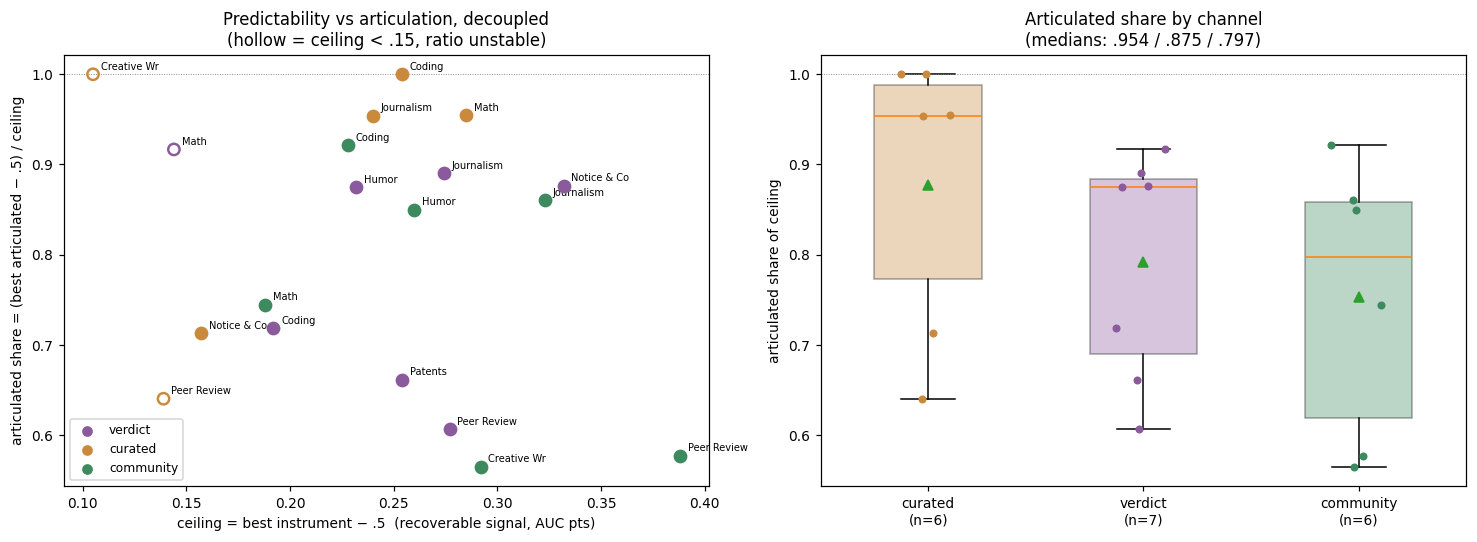

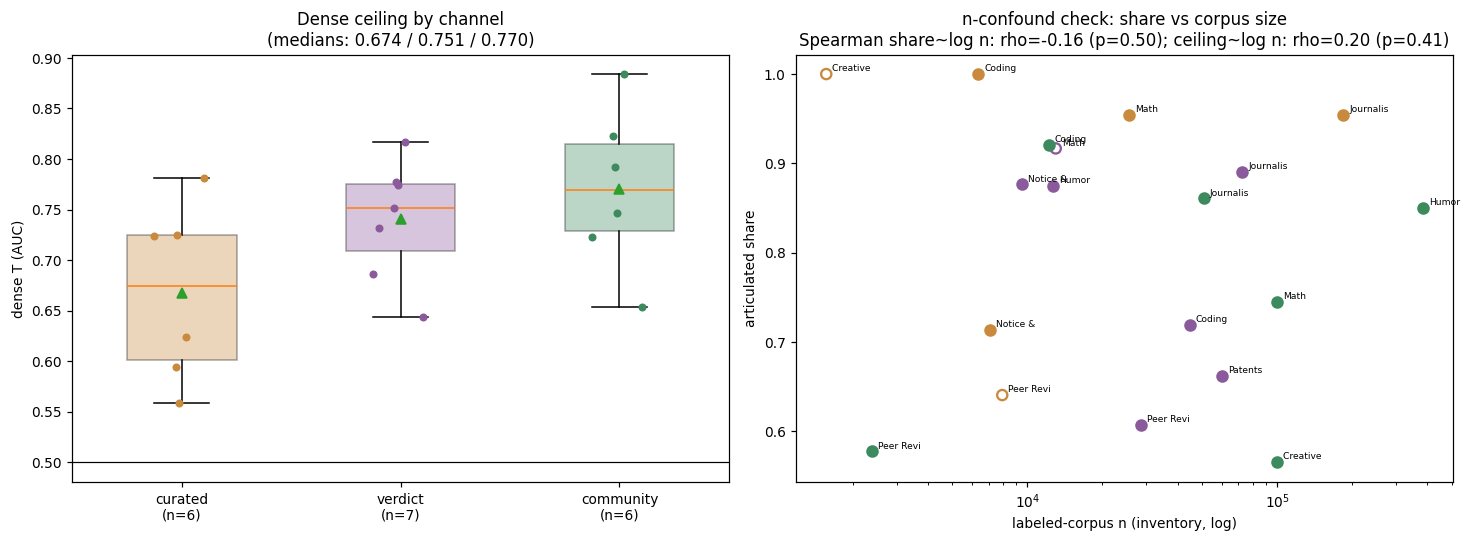

curated   share mean 0.877 median 0.954 | ceiling mean 0.197
verdict   share mean 0.792 median 0.875 | ceiling mean 0.244
community share mean 0.753 median 0.797 | ceiling mean 0.280
median corpus n by channel: {'curated': 7512, 'verdict': 28402, 'community': 75377}
counterexamples: peer-cites n=2,387 -> LARGEST ceiling (.388); Wigleaf n=1,568 -> smallest (.105);
homepage n=183,708 -> dense .725 still <= bank .729. n alone does not set the ceiling.


In [ ]:
# ARTICULATED-SHARE NORMALIZATION (2026-08-18, user request): decouple the raw
# residual gap into (i) CEILING = how much preference is recoverable at all
# (best instrument - .5) and (ii) ARTICULATED SHARE = fraction of that ceiling
# reached by the best fully-articulated column, max(V, V_new, V+A, V+A_new).
# The claim this readout supports is exactly: "what % of recoverable shared
# preference is articulated" -- NOT "how predictable is the channel".
# NOTE vs the raw-gap boxplot above: that plot used plain V+A; here mined
# V+A_new counts as articulated (it is), which moves Humor-verdict from the
# .20 outlier to share .875 (VA .529 pre-mining -> VA_new .703).
import numpy as np, matplotlib.pyplot as plt

rows = []
for ytype, D in (("verdict", VERDICT), ("curated", CURATION), ("community", COMMUNITY)):
    for f, tup in D.items():
        V, Vn, VA, VAn, VAT, T = tup[:6]
        artic = [x for x in (V, Vn, VA, VAn) if x is not None]
        allc = [x for x in (V, Vn, VA, VAn, VAT, T) if x is not None]
        if not artic or not allc or max(allc) <= .5:
            continue
        A, B = max(artic), max(allc)
        rows.append(dict(field=f.replace("\n", " "), ytype=ytype, ceil=B - .5,
                         share=(A - .5) / (B - .5), van=VAn is not None))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5))
COL = {"verdict": "#8a5a9c", "curated": "#c98a3d", "community": "#3d8a5f"}
for r in rows:
    unstable = r["ceil"] < .15
    ax1.scatter(r["ceil"], r["share"], s=55, color=COL[r["ytype"]],
                facecolors="none" if unstable else COL[r["ytype"]],
                linewidths=1.6, zorder=5)
    ax1.annotate(f"{r['field'][:11]}", (r["ceil"], r["share"]), fontsize=6.5,
                 xytext=(5, 3), textcoords="offset points")
ax1.set_xlabel("ceiling = best instrument − .5  (recoverable signal, AUC pts)")
ax1.set_ylabel("articulated share = (best articulated − .5) / ceiling")
ax1.set_title("Predictability vs articulation, decoupled\n(hollow = ceiling < .15, ratio unstable)")
ax1.axhline(1.0, color="gray", lw=.6, ls=":")
for t, c in COL.items():
    ax1.scatter([], [], color=c, label=t)
ax1.legend(fontsize=8, loc="lower left")

YT = ["curated", "verdict", "community"]  # user-ordered 2026-08-18
data = [[r["share"] for r in rows if r["ytype"] == t] for t in YT]
bp = ax2.boxplot(data, tick_labels=[f"{t}\n(n={len(d)})" for t, d in zip(YT, data)],
                 showmeans=True, patch_artist=True, widths=.5)
for patch, t in zip(bp["boxes"], YT):
    patch.set_facecolor(COL[t]); patch.set_alpha(.35)
for i, t in enumerate(YT):
    pts = [r for r in rows if r["ytype"] == t]
    xs = np.random.default_rng(3).normal(i + 1, .05, len(pts))
    ax2.scatter(xs, [r["share"] for r in pts], s=18, color=COL[t], zorder=5)
ax2.set_ylabel("articulated share of ceiling")
ax2.set_title("Articulated share by channel\n(medians: .954 / .875 / .797)")
ax2.axhline(1.0, color="gray", lw=.6, ls=":")
plt.tight_layout(); plt.savefig("fig_articulated_share.png", bbox_inches="tight", dpi=110)
plt.show()
for t, d in zip(YT, data):
    ce = [r["ceil"] for r in rows if r["ytype"] == t]
    print(f"{t:9s} share mean {np.mean(d):.3f} median {np.median(d):.3f} | ceiling mean {np.mean(ce):.3f}")
# CAVEATS: mixed frames (campaign/E-refit/within-repo, per master-ladder notes);
# cells without a V+A_new column (5 of 19) have share as a LOWER bound; nothing
# here is deconfounded -- descriptive normalization of the same ladder numbers.

# --- PANEL 3 + n-CONFOUND CHECK (2026-08-18, user request) -------------------
# "AUC ceiling of dense across each channel" + test of "curated is articulable
# only because its cells are small and dense is data-starved".  n from the
# paper-3 PreferenceBench inventory (verified 2026-08-18); labeled-corpus size,
# a PROXY for dense training data (scored-cell sizes differ for some cells).
N_INV = {("verdict","Math"):13001, ("verdict","Coding"):44751,
 ("verdict","Notice & Comment"):9521, ("verdict","Patents"):59937,
 ("verdict","Peer Review"):28402, ("verdict","Journalism"):72315,
 ("verdict","Humor"):12734,
 ("curated","Math"):25454, ("curated","Coding"):6353,
 ("curated","Notice & Comment"):7084, ("curated","Peer Review"):7941,
 ("curated","Journalism"):183708, ("curated","Creative Writing"):1568,
 ("community","Math"):100000, ("community","Coding"):12202,
 ("community","Peer Review"):2387, ("community","Journalism"):50761,
 ("community","Creative Writing"):99994, ("community","Humor"):383786}
Ts = {}
for ytype, D in (("verdict", VERDICT), ("curated", CURATION), ("community", COMMUNITY)):
    for f, tup in D.items():
        if tup[5] is not None:
            Ts[(ytype, f.replace("\n", " "))] = tup[5]
fig2, (axT, axN) = plt.subplots(1, 2, figsize=(13.5, 5))
dataT = [[Ts[(t, r["field"])] for r in rows if r["ytype"] == t and (t, r["field"]) in Ts] for t in YT]
bpT = axT.boxplot(dataT, tick_labels=[f"{t}\n(n={len(d)})" for t, d in zip(YT, dataT)],
                  showmeans=True, patch_artist=True, widths=.5)
for patch, t in zip(bpT["boxes"], YT):
    patch.set_facecolor(COL[t]); patch.set_alpha(.35)
for i, t in enumerate(YT):
    vals = dataT[i]
    xs = np.random.default_rng(3).normal(i + 1, .05, len(vals))
    axT.scatter(xs, vals, s=18, color=COL[t], zorder=5)
axT.axhline(.5, color="k", lw=.8)
axT.set_ylabel("dense T (AUC)")
axT.set_title("Dense ceiling by channel\n(medians: %.3f / %.3f / %.3f)"
              % tuple(np.median(d) for d in dataT))
from scipy.stats import spearmanr
xs_n, ys_sh, ys_ce = [], [], []
for r in rows:
    key = (r["ytype"], r["field"])
    if key in N_INV:
        xs_n.append(np.log10(N_INV[key])); ys_sh.append(r["share"]); ys_ce.append(r["ceil"])
        axN.scatter(N_INV[key], r["share"], s=45, color=COL[r["ytype"]],
                    facecolors="none" if r["ceil"] < .15 else COL[r["ytype"]], linewidths=1.5)
        axN.annotate(r["field"][:9], (N_INV[key], r["share"]), fontsize=6, xytext=(4, 2),
                     textcoords="offset points")
axN.set_xscale("log"); axN.set_xlabel("labeled-corpus n (inventory, log)")
axN.set_ylabel("articulated share")
rs, ps = spearmanr(xs_n, ys_sh); rc, pc = spearmanr(xs_n, ys_ce)
axN.set_title("n-confound check: share vs corpus size\n"
              f"Spearman share~log n: rho={rs:.2f} (p={ps:.2f}); ceiling~log n: rho={rc:.2f} (p={pc:.2f})")
plt.tight_layout(); plt.savefig("fig_dense_ceiling_nconfound.png", bbox_inches="tight", dpi=110)
plt.show()
med_n = {t: np.median([N_INV[(t, r["field"])] for r in rows if r["ytype"] == t and (t, r["field"]) in N_INV]) for t in YT}
print("median corpus n by channel:", {k: int(v) for k, v in med_n.items()})
print("counterexamples: peer-cites n=2,387 -> LARGEST ceiling (.388); Wigleaf n=1,568 -> smallest (.105);")
print("homepage n=183,708 -> dense .725 still <= bank .729. n alone does not set the ceiling.")
